<div align="center">

# 🌊 Oil Spill Detection with Deep Learning
### Semantic Segmentation of Satellite Imagery — U-Net / DeepLabV3+ with a full evaluation suite and a Streamlit deployment layer

*Infosys Springboard Internship Project — refined edition*

</div>

---

**What this notebook does, end to end:**

1. Loads and explores a paired image/mask satellite dataset
2. Cleans images with a bilateral filter and builds an augmentation pipeline
3. Trains a configurable segmentation model (U-Net or DeepLabV3+, swappable encoder) with a
   configurable loss (Dice+BCE or Dice+Focal)
4. Tracks loss/IoU curves, and reports a **full metric suite** — pixel accuracy, precision,
   recall, specificity, F1, IoU, Dice, confusion matrix, and ROC/PR-AUC — not just IoU
5. Visualizes predictions, per-pixel error maps (TP / FP / FN), and a confusion matrix heatmap
6. Optionally evaluates with test-time augmentation (TTA) for a small, free accuracy boost
7. Ships a polished Streamlit app for interactive inference, deployable via a public tunnel

> **Why these choices:** a quick literature check on oil-spill segmentation research informed a
> few decisions here. Comparative studies of segmentation CNNs on SAR oil-spill imagery have
> found DeepLabV3+ (encoder + atrous spatial pyramid pooling) frequently edges out plain U-Net,
> and that combining Focal loss with an overlap-based loss (Dice/IoU) sharpens the model's
> confidence at spill boundaries where plain BCE tends to blur. Both of those are wired in here
> as *options* — the notebook defaults to the same U-Net + ResNet34 you started with, but
> switching to DeepLabV3+ or the Focal+Dice loss is a one-line change in `Config`, so you can
> actually run the comparison yourself and see which wins on your data.

> **Environment:** written for Google Colab with a GPU runtime and data stored on Google Drive.
> Everything is driven from a single `CONFIG` object in Section 1.

> ⚠️ **Security note:** the original notebook had a live ngrok authtoken hardcoded in a cell.
> This version never stores secrets in code — it asks for the token securely at runtime with
> `getpass`. If that old token was ever pushed anywhere public, revoke it at
> https://dashboard.ngrok.com/tunnels/authtokens and generate a new one.

## 📑 Contents

1. [Setup & Configuration](#1)
2. [Data Exploration](#2)
3. [Preprocessing (Denoising)](#3)
4. [Augmentation Pipeline](#4)
5. [Dataset & DataLoaders](#5)
6. [Pixel-Intensity Analysis](#6)
7. [Model Architecture](#7)
8. [Loss Functions](#8)
9. [Metrics Suite](#9)
10. [Training Loop](#10)
11. [Training Curves](#11)
12. [Final Evaluation (full metrics + confusion matrix)](#12)
13. [Qualitative Results & Error Maps](#13)
14. [Test-Time Augmentation (optional accuracy boost)](#14)
15. [Architecture Comparison Harness (optional)](#15)
16. [Streamlit App](#16)
17. [Deployment](#17)

<a id="1"></a>
## 1. Setup & Configuration

**Mount Google Drive** — this is where your `images/`, `masks/` folders and saved checkpoints live. Skips cleanly if you're not in Colab.

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not running in Colab — skipping Drive mount.")

Mounted at /content/drive


**Install dependencies not preinstalled in Colab.** `segmentation-models-pytorch` gives us both U-Net and DeepLabV3+ with pretrained encoders out of the box, instead of hand-writing each architecture.

In [ ]:
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00


**Imports and reproducibility.** Seeding random/numpy/torch means re-running this notebook gives you the same train/val split and the same augmentation sequence, which makes comparing two training runs meaningful.

In [ ]:
import os
import random
import json
from dataclasses import dataclass, field

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score
from tqdm import tqdm

def set_seed(seed: int = 42):
    # Fix every source of randomness we control, so runs are comparable.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


**The `Config` object** — every path and hyperparameter used below lives here. A couple of
fields are new compared to the original notebook:

- `architecture`: `"unet"` or `"deeplabv3plus"` — swap the whole segmentation head in one line
- `encoder_name`: any encoder `segmentation-models-pytorch` supports (`resnet34`, `resnet50`,
  `efficientnet-b3`, ...) — note there's no such thing as "ResNet32"; the standard family is
  ResNet-18/34/50/101/152, and your original notebook was already using ResNet-**34**, which is
  a perfectly solid, fast-training backbone, not a weak one
- `loss_type`: `"dice_bce"` (what you had) or `"dice_focal"` (better for very imbalanced masks)
- `use_amp`: mixed-precision training — meaningfully faster on a Colab GPU with no accuracy cost

In [ ]:
@dataclass
class Config:
    # Data
    image_dir: str = "/content/drive/MyDrive/images"
    mask_dir: str = "/content/drive/MyDrive/masks"
    filtered_image_dir: str = "/content/drive/MyDrive/new_filtered_images"
    checkpoint_path: str = "/content/drive/MyDrive/best_model_custom_unet.pth.tar"
    history_path: str = "/content/drive/MyDrive/training_history.json"
    metrics_path: str = "/content/drive/MyDrive/final_metrics.json"
    plots_dir: str = "/content/drive/MyDrive/plots" # New: Directory to save plots

    # Image
    img_size: int = 256

    # Model — swap architecture/encoder here, nowhere else
    architecture: str = "unet"          # "unet" or "deeplabv3plus"
    encoder_name: str = "resnet34"      # e.g. "resnet34", "resnet50", "efficientnet-b3"
    encoder_weights: str = "imagenet"

    # Loss
    loss_type: str = "dice_bce"         # "dice_bce" or "dice_focal"
    bce_weight: float = 0.5             # used when loss_type == "dice_bce"
    focal_gamma: float = 2.0            # used when loss_type == "dice_focal"
    dice_weight: float = 0.5            # weight of the overlap term either way

    # Training
    batch_size: int = 16
    num_workers: int = 2
    learning_rate: float = 1e-4
    num_epochs: int = 50
    early_stop_patience: int = 7
    val_split: float = 0.2
    use_amp: bool = True                # mixed precision — faster, same accuracy
    grad_clip_norm: float = 1.0

    # Evaluation
    use_tta: bool = False               # flip-averaged inference, Section 14

CFG = Config()
os.makedirs(CFG.filtered_image_dir, exist_ok=True)
os.makedirs(CFG.plots_dir, exist_ok=True) # New: Create plots directory
print(CFG)

Config(image_dir='/content/drive/MyDrive/images', mask_dir='/content/drive/MyDrive/masks', filtered_image_dir='/content/drive/MyDrive/new_filtered_images', checkpoint_path='/content/drive/MyDrive/best_model_custom_unet.pth.tar', history_path='/content/drive/MyDrive/training_history.json', metrics_path='/content/drive/MyDrive/final_metrics.json', plots_dir='/content/drive/MyDrive/plots', img_size=256, architecture='unet', encoder_name='resnet34', encoder_weights='imagenet', loss_type='dice_bce', bce_weight=0.5, focal_gamma=2.0, dice_weight=0.5, batch_size=16, num_workers=2, learning_rate=0.0001, num_epochs=50, early_stop_patience=7, val_split=0.2, use_amp=True, grad_clip_norm=1.0, use_tta=False)


<a id="2"></a>
## 2. Data Exploration

Confirm the dataset is where we expect it, that image/mask counts line up, and eyeball a few
image–mask pairs before doing anything else.

**Count and sanity-check.** An assertion here fails loudly and immediately if images and masks are out of sync, instead of silently mismatching them at training time — that kind of bug is very hard to catch from a loss curve.

In [ ]:
image_files = sorted(os.listdir(CFG.image_dir))
mask_files = sorted(os.listdir(CFG.mask_dir))

assert len(image_files) == len(mask_files), (
    f"Image/mask count mismatch: {len(image_files)} images vs {len(mask_files)} masks"
)

print(f"Total images: {len(image_files)}")
print(f"Total masks:  {len(mask_files)}")
print(f"Sample images: {image_files[:5]}")
print(f"Sample masks:  {mask_files[:5]}")

Total images: 811
Total masks:  811
Sample images: ['Oil (1).jpg', 'Oil (10).jpg', 'Oil (100).jpg', 'Oil (1000).jpg', 'Oil (1001).jpg']
Sample masks:  ['Oil (1).png', 'Oil (10).png', 'Oil (100).png', 'Oil (1000).png', 'Oil (1001).png']


**Visual spot-check.** Pulls a few random image/mask pairs so you can confirm the masks actually line up with visible spill regions before spending compute on training.

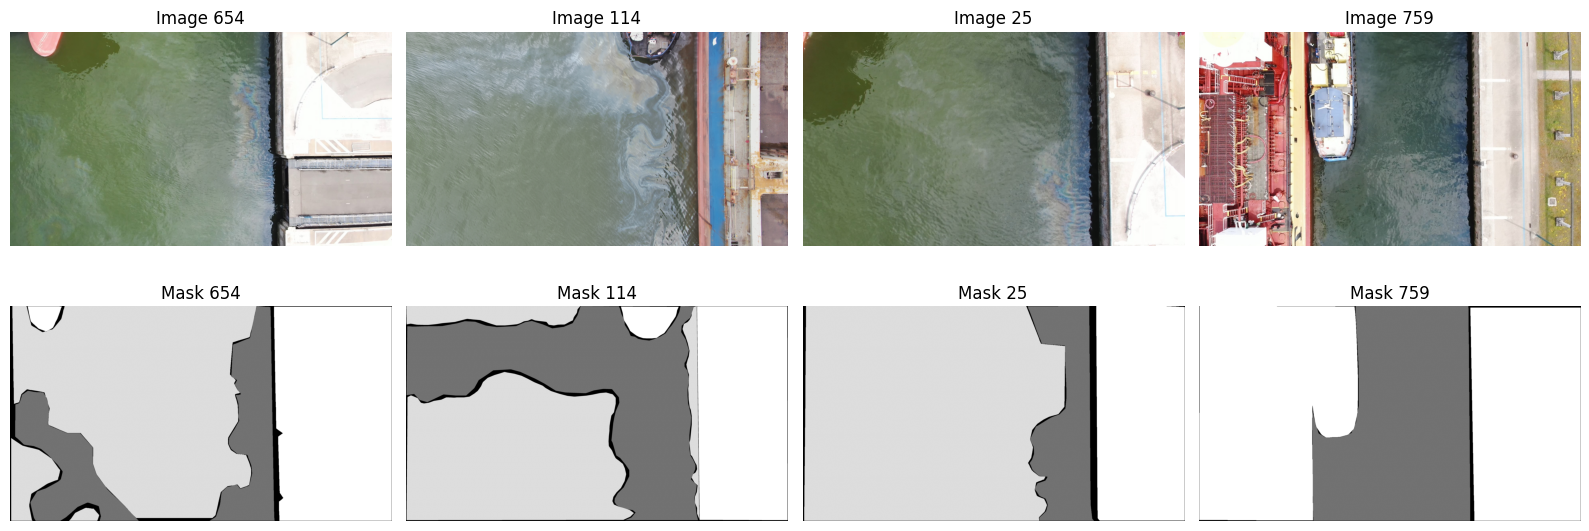

In [ ]:
def load_pair(idx, image_dir=CFG.image_dir, mask_dir=CFG.mask_dir):
    img = cv2.cvtColor(cv2.imread(os.path.join(image_dir, image_files[idx])), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(mask_dir, mask_files[idx]), cv2.IMREAD_GRAYSCALE)
    return img, mask

def show_pairs(indices, image_dir=CFG.image_dir, mask_dir=CFG.mask_dir, title_prefix=""):
    n = len(indices)
    plt.figure(figsize=(4 * n, 6))
    for i, idx in enumerate(indices):
        img, mask = load_pair(idx, image_dir, mask_dir)
        plt.subplot(2, n, i + 1)
        plt.imshow(img); plt.title(f"{title_prefix}Image {idx}"); plt.axis("off")
        plt.subplot(2, n, n + i + 1)
        plt.imshow(mask, cmap="gray"); plt.title(f"{title_prefix}Mask {idx}"); plt.axis("off")
    plt.tight_layout()
    plt.show()

sample_indices = random.sample(range(len(image_files)), min(4, len(image_files)))
show_pairs(sample_indices)

<a id="3"></a>
## 3. Preprocessing — Bilateral Filter Denoising

Satellite images carry sensor noise that can be mistaken for texture by the model. A bilateral
filter smooths noise while preserving edges (the spill boundary), which is exactly the trade-off
we want before training. This only needs to run once — the results are cached to disk.

**Denoise once, cache forever.** Re-running this cell is a no-op if the filtered folder already has as many files as the source folder, so you can re-run the whole notebook top-to-bottom without redoing this every time.

In [ ]:
def denoise_dataset(image_dir=CFG.image_dir, out_dir=CFG.filtered_image_dir, force=False):
    os.makedirs(out_dir, exist_ok=True)
    already_done = len(os.listdir(out_dir)) == len(os.listdir(image_dir))
    if already_done and not force:
        print(f"Filtered images already present in {out_dir} — skipping (pass force=True to redo).")
        return

    for img_file in tqdm(os.listdir(image_dir), desc="Bilateral filtering"):
        img_path = os.path.join(image_dir, img_file)
        img_color = cv2.imread(img_path)
        if img_color is None:
            print(f"Warning: could not read {img_path}, skipping.")
            continue
        # d=9: neighborhood diameter. sigmaColor/sigmaSpace=75: how much color/space
        # difference is still considered "the same surface" and gets smoothed together.
        filtered = cv2.bilateralFilter(img_color, d=9, sigmaColor=75, sigmaSpace=75)
        cv2.imwrite(os.path.join(out_dir, img_file), filtered)

    print(f"Done. Cleaned images saved to: {out_dir}")

denoise_dataset()

Filtered images already present in /content/drive/MyDrive/new_filtered_images — skipping (pass force=True to redo).


<a id="4"></a>
## 4. Augmentation Pipeline

Spills have no canonical orientation and satellite lighting varies, so the pipeline leans on
flips/rotation plus mild photometric jitter. `A.Normalize` is applied last so every tensor the
model sees is already zero-centered.

**Two separate pipelines, on purpose.** Training gets randomized flips/rotation/color jitter for variety. Validation only gets resize + normalize — no randomness. Sharing one augmenting transform between train and val (as the original notebook did) quietly inflates validation scores, because the model is being evaluated on easier, jittered copies rather than the real held-out data.

In [ ]:
train_transform = A.Compose([
    A.Resize(CFG.img_size, CFG.img_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(scale_limit=0.1, rotate_limit=25, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=25, val_shift_limit=15, p=0.4),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0)),
])

val_transform = A.Compose([
    A.Resize(CFG.img_size, CFG.img_size),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0)),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


**Visual sanity check of the augmentations** — image / mask / overlay for a handful of random augmented samples, so you can eyeball that masks are still aligned with images after each transform (a bug here is easy to introduce and easy to miss).

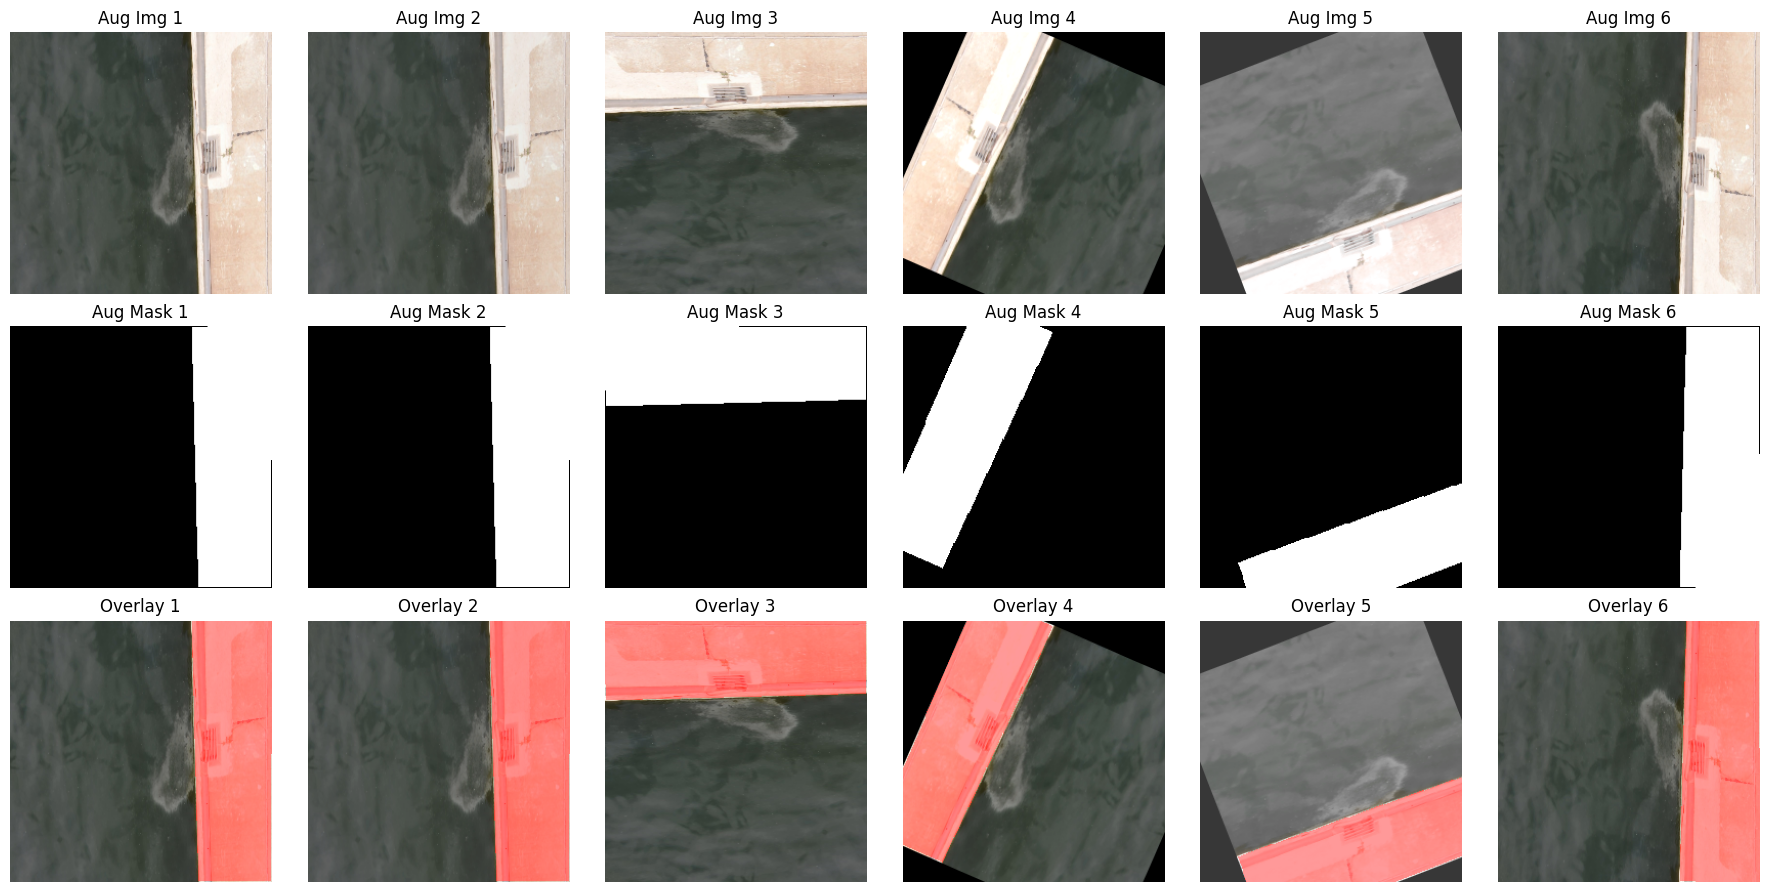

In [ ]:
def overlay_mask_np(img, msk, color=(255, 0, 0), alpha=0.4):
    overlay = img.copy()
    overlay[msk == 1] = color
    return cv2.addWeighted(img, 1 - alpha, overlay, alpha, 0)

idx = random.randint(0, len(image_files) - 1)
img, mask = load_pair(idx, CFG.filtered_image_dir if os.path.exists(CFG.filtered_image_dir) else CFG.image_dir)
mask_bin = (mask > 127).astype(np.uint8)

num_augs = 6
plt.figure(figsize=(3 * num_augs, 9))
for i in range(num_augs):
    augmented = train_transform(image=img, mask=mask_bin)
    aug_img, aug_mask = augmented["image"], augmented["mask"]

    plt.subplot(3, num_augs, i + 1)
    plt.imshow(aug_img); plt.title(f"Aug Img {i+1}"); plt.axis("off")

    plt.subplot(3, num_augs, num_augs + i + 1)
    plt.imshow(aug_mask, cmap="gray"); plt.title(f"Aug Mask {i+1}"); plt.axis("off")

    plt.subplot(3, num_augs, 2 * num_augs + i + 1)
    plt.imshow(overlay_mask_np(aug_img, aug_mask)); plt.title(f"Overlay {i+1}"); plt.axis("off")
plt.tight_layout()
plt.show()

<a id="5"></a>
## 5. Dataset & DataLoaders

A `torch.utils.data.Dataset` wrapping the filtered images and binarized masks, split 80/20 into
train/validation.

**The Dataset class.** Loads an image/mask pair, binarizes the mask at a 127 threshold, applies whichever transform it's given, and returns CHW float tensors — the shape PyTorch conv layers expect.

In [ ]:
class OilSpillDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented["image"], augmented["mask"]

        image = torch.tensor(image.transpose(2, 0, 1), dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)
        return image, mask

**Split and build loaders.** The same index split is applied to two *separately constructed* dataset instances — one with `train_transform`, one with `val_transform` — via `Subset`, which is how train/val end up with different augmentation behavior despite drawing from the same underlying files.

Train dataset size: 649
Validation dataset size: 162


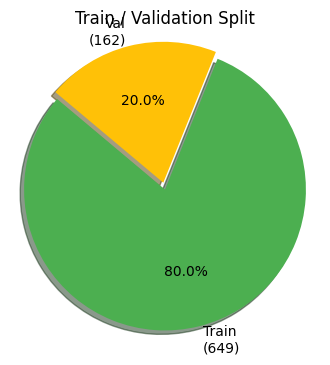

In [ ]:
full_dataset = OilSpillDataset(CFG.filtered_image_dir, CFG.mask_dir, transform=None)

val_size = int(CFG.val_split * len(full_dataset))
train_size = len(full_dataset) - val_size

generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(range(len(full_dataset)), [train_size, val_size], generator=generator)

train_dataset = OilSpillDataset(CFG.filtered_image_dir, CFG.mask_dir, transform=train_transform)
val_dataset = OilSpillDataset(CFG.filtered_image_dir, CFG.mask_dir, transform=val_transform)
train_dataset = torch.utils.data.Subset(train_dataset, train_indices.indices)
val_dataset = torch.utils.data.Subset(val_dataset, val_indices.indices)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)
val_loader = DataLoader(val_dataset, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers)

plt.figure(figsize=(4, 4))
plt.pie(
    [train_size, val_size],
    explode=(0.05, 0),
    labels=[f"Train\n({train_size})", f"Val\n({val_size})"],
    colors=["#4CAF50", "#FFC107"],
    autopct="%1.1f%%",
    shadow=True,
    startangle=140,
)
plt.axis("equal")
plt.title("Train / Validation Split")
plt.savefig(os.path.join(CFG.plots_dir, "train_val_split.png")) # Save plot
plt.show()

<a id="6"></a>
## 6. Pixel-Intensity Analysis

A quick class-separability check: do spill and non-spill pixels actually look different in
intensity? If these distributions overlapped heavily, that alone would predict a hard learning
problem — this is a cheap sanity check before spending GPU hours on training.

**Accumulate per-class intensity statistics** across the whole dataset (not just one image), then plot both histograms together. Distinct peaks are a good sign; heavy overlap tells you texture/context features will matter more than raw brightness.

Scanning pixel intensities: 100%|██████████| 811/811 [01:10<00:00, 11.56it/s]


Spill region     — mean: 141.39, std: 50.27
Non-spill region — mean: 103.03, std: 55.90


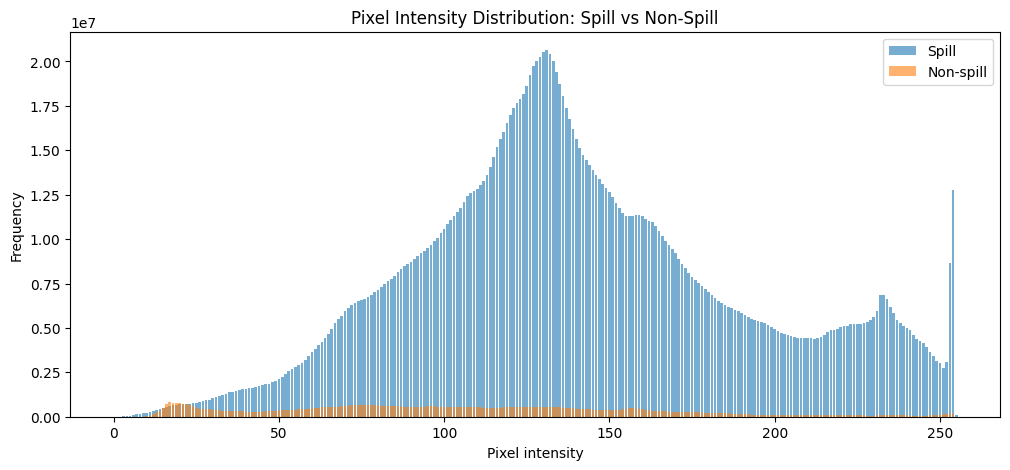

In [ ]:
def intensity_stats(image_dir=CFG.filtered_image_dir, mask_dir=CFG.mask_dir):
    spill_sum = spill_sum_sq = spill_count = 0
    nonspill_sum = nonspill_sum_sq = nonspill_count = 0
    spill_hist = np.zeros(256)
    nonspill_hist = np.zeros(256)

    for img_file, mask_file in tqdm(list(zip(sorted(os.listdir(image_dir)), sorted(os.listdir(mask_dir)))),
                                     desc="Scanning pixel intensities"):
        img = cv2.imread(os.path.join(image_dir, img_file), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(os.path.join(mask_dir, mask_file), cv2.IMREAD_GRAYSCALE)

        spill_px = img[mask > 0]
        spill_sum += spill_px.sum(); spill_sum_sq += (spill_px.astype(np.int64) ** 2).sum()
        spill_count += spill_px.size
        spill_hist += np.bincount(spill_px, minlength=256)

        nonspill_px = img[mask == 0]
        nonspill_sum += nonspill_px.sum(); nonspill_sum_sq += (nonspill_px.astype(np.int64) ** 2).sum()
        nonspill_count += nonspill_px.size
        nonspill_hist += np.bincount(nonspill_px, minlength=256)

    spill_mean = spill_sum / spill_count
    spill_std = np.sqrt(spill_sum_sq / spill_count - spill_mean ** 2)
    nonspill_mean = nonspill_sum / nonspill_count
    nonspill_std = np.sqrt(nonspill_sum_sq / nonspill_count - nonspill_mean ** 2)

    print(f"Spill region     — mean: {spill_mean:.2f}, std: {spill_std:.2f}")
    print(f"Non-spill region — mean: {nonspill_mean:.2f}, std: {nonspill_std:.2f}")

    plt.figure(figsize=(12, 5))
    plt.bar(range(256), spill_hist, alpha=0.6, label="Spill")
    plt.bar(range(256), nonspill_hist, alpha=0.6, label="Non-spill")
    plt.xlabel("Pixel intensity"); plt.ylabel("Frequency")
    plt.title("Pixel Intensity Distribution: Spill vs Non-Spill")
    plt.legend()
    plt.savefig(os.path.join(CFG.plots_dir, "pixel_intensity_distribution.png")) # Save plot
    plt.show()

intensity_stats()

<a id="7"></a>
## 7. Model Architecture

`build_model()` is a small factory over `segmentation-models-pytorch`, so `CFG.architecture` and
`CFG.encoder_name` fully determine what gets built — no duplicated model-definition code scattered
around the notebook.

- **U-Net** (your original choice): encoder-decoder with skip connections, strong at preserving
  fine spatial detail — a good fit when spill boundaries matter.
- **DeepLabV3+**: adds Atrous Spatial Pyramid Pooling (dilated convolutions at multiple rates) on
  top of the encoder, which widens the receptive field without losing resolution. Comparative
  studies on oil-spill SAR segmentation have reported DeepLabV3+ edging out plain U-Net-style
  models — worth trying on your own data via `CFG.architecture = "deeplabv3plus"`.

Both use a ResNet (or other) encoder pretrained on ImageNet, which matters most when your labeled
dataset is small — the encoder already knows general edges/textures and only needs to adapt to
this domain.

In [ ]:
def build_model(architecture=None, encoder_name=None, encoder_weights=None):
    architecture = architecture or CFG.architecture
    encoder_name = encoder_name or CFG.encoder_name
    encoder_weights = CFG.encoder_weights if encoder_weights is None else encoder_weights

    if architecture == "unet":
        model = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
        )
    elif architecture == "deeplabv3plus":
        model = smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
        )
    else:
        raise ValueError(f"Unknown architecture: {architecture}")

    return model.to(DEVICE)

model = build_model()
n_params = sum(p.numel() for p in model.parameters())
print(f"{CFG.architecture} ({CFG.encoder_name} encoder) created — {n_params/1e6:.1f}M parameters.")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

unet (resnet34 encoder) created — 24.4M parameters.


<a id="8"></a>
## 8. Loss Functions

Oil spills typically cover a small fraction of each image, so pixel-wise BCE alone is easily
dominated by the "no spill" background class. Two combined losses are provided, selected by
`CFG.loss_type`:

- **`dice_bce`** (your original): Dice loss (rewards mask overlap regardless of class balance)
  blended with standard BCE.
- **`dice_focal`**: Dice blended with **Focal loss** instead of plain BCE. Focal loss
  down-weights pixels the model already classifies confidently and correctly, forcing training
  to keep pushing on the hard/ambiguous pixels — usually the spill *boundary*. Research on SAR
  oil-spill segmentation specifically credits a Focal+overlap loss combination with sharper,
  more confident boundary predictions than BCE-based losses.

Try both and compare the final metrics table in Section 12 — that's a real, cheap way to find
out which suits your dataset rather than assuming.

In [ ]:
class DiceLoss(nn.Module):
    def forward(self, inputs, targets, smooth=1e-6):
        inputs = torch.sigmoid(inputs).view(-1)
        targets = targets.view(-1)
        intersection = (inputs * targets).sum()
        dice = (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        return 1 - dice

class FocalLoss(nn.Module):
    # Down-weights easy, already-correct pixels so training focuses on hard ones.
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
        probs = torch.sigmoid(inputs)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_term = alpha_t * (1 - p_t) ** self.gamma
        return (focal_term * bce).mean()

class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=CFG.bce_weight):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = DiceLoss()

    def forward(self, inputs, targets):
        targets_bce = targets.float().unsqueeze(1) if targets.dim() == 3 else targets.float()
        bce = self.bce_loss(inputs, targets_bce)
        dice = self.dice_loss(inputs, targets)
        return self.bce_weight * bce + (1 - self.bce_weight) * dice

class DiceFocalLoss(nn.Module):
    def __init__(self, dice_weight=CFG.dice_weight, gamma=CFG.focal_gamma):
        super().__init__()
        self.dice_weight = dice_weight
        self.focal_loss = FocalLoss(gamma=gamma)
        self.dice_loss = DiceLoss()

    def forward(self, inputs, targets):
        targets_focal = targets.float().unsqueeze(1) if targets.dim() == 3 else targets.float()
        focal = self.focal_loss(inputs, targets_focal)
        dice = self.dice_loss(inputs, targets)
        return (1 - self.dice_weight) * focal + self.dice_weight * dice

def build_loss(loss_type=None):
    loss_type = loss_type or CFG.loss_type
    if loss_type == "dice_bce":
        return DiceBCELoss()
    elif loss_type == "dice_focal":
        return DiceFocalLoss()
    raise ValueError(f"Unknown loss_type: {loss_type}")

loss_fn = build_loss()
print(f"Loss ready: {CFG.loss_type}")

Loss ready: dice_bce


<a id="9"></a>
## 9. Metrics Suite

The original notebook only reported IoU. That's a reasonable headline number for segmentation,
but it hides a lot — a model could have great IoU on easy images and be unreliable on hard ones,
or have decent overlap but a high false-positive rate that would flood a monitoring dashboard
with false alerts.

`MetricAccumulator` fixes a subtler issue too: averaging a metric like IoU *per batch, then
across batches* is not the same number as computing it once over the *entire* concatenated
validation set, especially with a small last batch. This accumulates raw TP/FP/FN/TN pixel
counts across every batch first, and only computes ratios at the very end — the statistically
correct way to do it.

Metrics reported:
- **Pixel accuracy** — fraction of all pixels classified correctly (can be misleadingly high
  when the background class dominates, which is exactly why it's reported *alongside* the rest,
  not alone)
- **Precision** — of the pixels flagged as spill, what fraction actually are
- **Recall (a.k.a. Sensitivity)** — of the true spill pixels, what fraction were caught
- **Specificity** — of the true non-spill pixels, what fraction were correctly left alone
- **F1 score** — harmonic mean of precision and recall
- **IoU (Jaccard)** and **Dice** — the two standard segmentation-overlap metrics
- **ROC-AUC** and **PR-AUC** — computed on raw probabilities (before thresholding at 0.5),
  showing how good the model's confidence ranking is, independent of any one threshold choice

In [ ]:
class MetricAccumulator:
    def __init__(self, prob_sample_size=200_000):
        self.tp = self.fp = self.fn = self.tn = 0
        self.prob_sample_size = prob_sample_size
        self._probs = []
        self._labels = []

    def update(self, probs, targets, threshold=0.5):
        preds = (probs > threshold).float()
        targets = targets.float()

        self.tp += ((preds == 1) & (targets == 1)).sum().item()
        self.fp += ((preds == 1) & (targets == 0)).sum().item()
        self.fn += ((preds == 0) & (targets == 1)).sum().item()
        self.tn += ((preds == 0) & (targets == 0)).sum().item()

        # For AUC we only need a representative sample, not every pixel ever seen —
        # keeping all of them would blow up memory on a large validation set.
        flat_probs = probs.view(-1).detach().cpu().numpy()
        flat_targets = targets.view(-1).detach().cpu().numpy()
        if len(self._probs) < self.prob_sample_size:
            keep = min(len(flat_probs), self.prob_sample_size - len(self._probs))
            idx = np.random.choice(len(flat_probs), size=keep, replace=False)
            self._probs.append(flat_probs[idx])
            self._labels.append(flat_targets[idx])

    def compute(self, smooth=1e-6):
        tp, fp, fn, tn = self.tp, self.fp, self.fn, self.tn
        accuracy = (tp + tn) / (tp + fp + fn + tn + smooth)
        precision = tp / (tp + fp + smooth)
        recall = tp / (tp + fn + smooth)          # a.k.a. sensitivity
        specificity = tn / (tn + fp + smooth)
        f1 = 2 * precision * recall / (precision + recall + smooth)
        iou = tp / (tp + fp + fn + smooth)
        dice = 2 * tp / (2 * tp + fp + fn + smooth)

        probs = np.concatenate(self._probs) if self._probs else np.array([])
        labels = np.concatenate(self._labels) if self._labels else np.array([])
        roc_auc = pr_auc = float("nan")
        if len(np.unique(labels)) > 1:  # AUC is undefined with only one class present
            roc_auc = roc_auc_score(labels, probs)
            pr_auc = average_precision_score(labels, probs)

        return {
            "accuracy": accuracy, "precision": precision, "recall": recall,
            "specificity": specificity, "f1": f1, "iou": iou, "dice": dice,
            "roc_auc": roc_auc, "pr_auc": pr_auc,
            "confusion_matrix": {"tp": tp, "fp": fp, "fn": fn, "tn": tn},
        }

def print_metrics(metrics, title="Metrics"):
    print(f"--- {title} ---")
    for key in ["accuracy", "precision", "recall", "specificity", "f1", "iou", "dice", "roc_auc", "pr_auc"]:
        val = metrics[key]
        print(f"{key:>12}: {val*100:.2f}%" if not np.isnan(val) else f"{key:>12}: n/a")

<a id="10"></a>
## 10. Training Loop

Adam + cosine-annealed learning rate, early stopping on validation IoU, mixed precision for
speed, and gradient clipping for stability. Every epoch's train loss / val loss / val IoU / val
Dice is logged to `history` so Section 11 plots real learning curves instead of just the final
number.

**Per-epoch train/validate functions.** `use_amp` runs the forward/backward pass in reduced precision on GPU (roughly 1.5-2x faster on a Colab T4, no accuracy loss in practice) via `torch.cuda.amp`. Gradient clipping caps the gradient norm so a single bad batch can't destabilize training.

In [ ]:
scaler = torch.cuda.amp.GradScaler(enabled=CFG.use_amp)

def run_train_epoch(loader, model, optimizer, loss_fn):
    model.train()
    running_loss = 0.0
    loop = tqdm(loader, leave=False, desc="train")
    for data, targets in loop:
        data, targets = data.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=CFG.use_amp):
            preds = model(data)
            loss = loss_fn(preds, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * data.size(0)
        loop.set_postfix(loss=loss.item())
    return running_loss / len(loader.dataset)

def run_val_epoch(loader, model, loss_fn):
    model.eval()
    running_loss = 0.0
    accumulator = MetricAccumulator()
    with torch.no_grad():
        for data, targets in loader:
            data, targets = data.to(DEVICE), targets.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=CFG.use_amp):
                preds = model(data)
                loss = loss_fn(preds, targets)
            running_loss += loss.item() * data.size(0)

            probs = torch.sigmoid(preds).squeeze(1) if preds.dim() == 4 else torch.sigmoid(preds)
            accumulator.update(probs, targets)

    metrics = accumulator.compute()
    return running_loss / len(loader.dataset), metrics

/tmp/ipykernel_1920/3932451204.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CFG.use_amp)


**The main loop.** Trains for up to `CFG.num_epochs`, saves a checkpoint every time validation IoU improves, and stops early if it hasn't improved for `CFG.early_stop_patience` epochs — the same early-stopping logic as before, but now with the fuller metric suite logged per epoch too.

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=CFG.learning_rate)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.num_epochs)

history = {"train_loss": [], "val_loss": [], "val_iou": [], "val_dice": [], "val_f1": []}
best_val_iou = -1.0
epochs_no_improve = 0

print(f"--- Training {CFG.architecture}/{CFG.encoder_name} on {DEVICE} "
      f"for up to {CFG.num_epochs} epochs (patience={CFG.early_stop_patience}) ---")

for epoch in range(CFG.num_epochs):
    train_loss = run_train_epoch(train_loader, model, optimizer, loss_fn)
    val_loss, val_metrics = run_val_epoch(val_loader, model, loss_fn)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_metrics["iou"])
    history["val_dice"].append(val_metrics["dice"])
    history["val_f1"].append(val_metrics["f1"])

    print(f"Epoch [{epoch+1}/{CFG.num_epochs}] "
          f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
          f"val_iou={val_metrics['iou']:.4f}  val_dice={val_metrics['dice']:.4f}  "
          f"val_f1={val_metrics['f1']:.4f}")

    if val_metrics["iou"] > best_val_iou:
        best_val_iou = val_metrics["iou"]
        epochs_no_improve = 0
        torch.save({
            "state_dict": model.state_dict(),
            "config": CFG.__dict__,
            "val_metrics": val_metrics,
        }, CFG.checkpoint_path)
        print(f"  ✓ New best model saved (IoU={best_val_iou:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= CFG.early_stop_patience:
        print(f"Early stopping after {epoch+1} epochs.")
        break

with open(CFG.history_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"Training history saved to {CFG.history_path}")

--- Training unet/resnet34 on cuda for up to 50 epochs (patience=7) ---


train:   0%|          | 0/41 [00:00<?, ?it/s]/tmp/ipykernel_1920/3932451204.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.use_amp):
/tmp/ipykernel_1920/3932451204.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.use_amp):


Epoch [1/50] train_loss=0.3752  val_loss=0.2186  val_iou=0.8600  val_dice=0.9247  val_f1=0.9247
  ✓ New best model saved (IoU=0.8600)


train:   0%|          | 0/41 [00:00<?, ?it/s]/tmp/ipykernel_1920/3932451204.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.use_amp):
/tmp/ipykernel_1920/3932451204.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.use_amp):


Epoch [2/50] train_loss=0.2457  val_loss=0.1863  val_iou=0.8753  val_dice=0.9335  val_f1=0.9335
  ✓ New best model saved (IoU=0.8753)


...

Epoch [25/50] train_loss=0.0783  val_loss=0.0861  val_iou=0.9326  val_dice=0.9651  val_f1=0.9651
  No improvement for 5 epoch(s).


train:   0%|          | 0/41 [00:00<?, ?it/s]/tmp/ipykernel_1920/3932451204.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.use_amp):
/tmp/ipykernel_1920/3932451204.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.use_amp):


Epoch [26/50] train_loss=0.0854  val_loss=0.0830  val_iou=0.9327  val_dice=0.9652  val_f1=0.9652
  No improvement for 6 epoch(s).


train:   0%|          | 0/41 [00:00<?, ?it/s]/tmp/ipykernel_1920/3932451204.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.use_amp):
/tmp/ipykernel_1920/3932451204.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=CFG.use_amp):


Epoch [27/50] train_loss=0.0780  val_loss=0.0802  val_iou=0.9366  val_dice=0.9673  val_f1=0.9673
  No improvement for 7 epoch(s).
Early stopping after 27 epochs.
Training history saved to /content/drive/MyDrive/training_history.json


<a id="11"></a>
## 11. Training Curves

Loss and validation metrics over time — the first thing to check when a run looks disappointing
(still descending vs. plateaued vs. overfitting, i.e. train loss still falling while val loss
climbs back up).

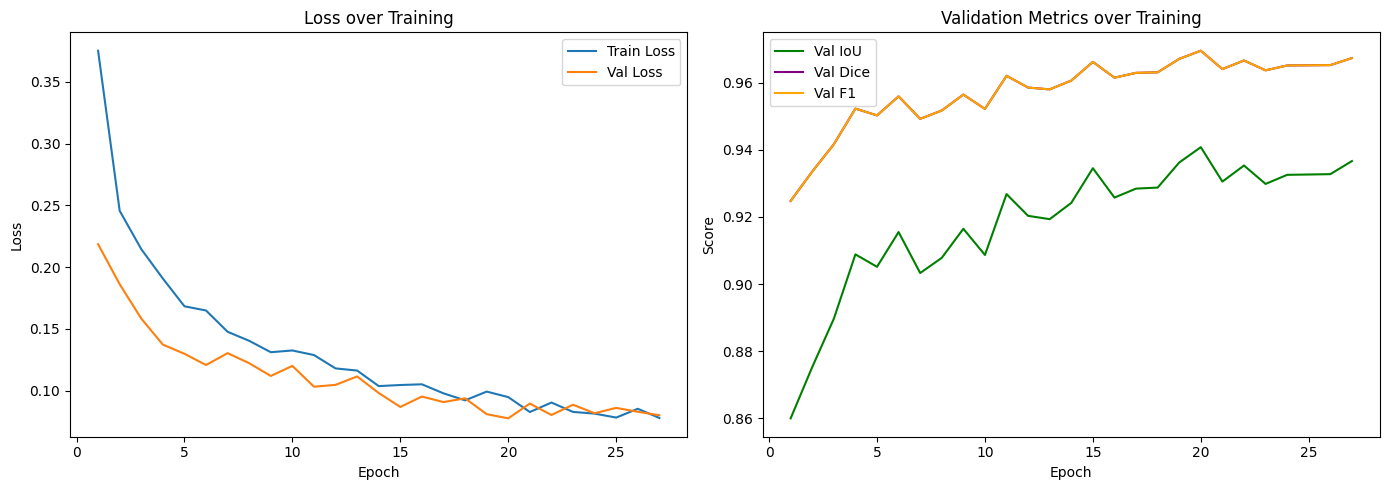

In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss over Training")
axes[0].legend()

axes[1].plot(epochs_range, history["val_iou"], label="Val IoU", color="green")
axes[1].plot(epochs_range, history["val_dice"], label="Val Dice", color="purple")
axes[1].plot(epochs_range, history["val_f1"], label="Val F1", color="orange")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score"); axes[1].set_title("Validation Metrics over Training")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CFG.plots_dir, "training_curves.png")) # Save plot
plt.show()

<a id="12"></a>
## 12. Final Evaluation — Full Metric Suite + Confusion Matrix

Reload the checkpoint that scored best on validation IoU (not necessarily the last epoch) and
report every metric from Section 9 on the full validation set, plus a confusion matrix heatmap
you can screenshot straight into a report or resume.

In [ ]:
best_model = build_model(encoder_weights=None)
checkpoint = torch.load(CFG.checkpoint_path, map_location=DEVICE, weights_only=False)
best_model.load_state_dict(checkpoint["state_dict"])
best_model.eval()
print(f"Loaded best checkpoint from {CFG.checkpoint_path}")

final_accumulator = MetricAccumulator()
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        probs = torch.sigmoid(best_model(x)).squeeze(1)
        final_accumulator.update(probs, y)

final_metrics = final_accumulator.compute()
print_metrics(final_metrics, title="Final Validation Performance")

with open(CFG.metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=2)
print(f"Saved to {CFG.metrics_path}")

Loaded best checkpoint from /content/drive/MyDrive/best_model_custom_unet.pth.tar
--- Final Validation Performance ---
    accuracy: 96.01%
   precision: 96.29%
      recall: 97.62%
 specificity: 93.03%
          f1: 96.95%
         iou: 94.08%
        dice: 96.95%
     roc_auc: 99.23%
      pr_auc: 99.57%
Saved to /content/drive/MyDrive/final_metrics.json


**Confusion matrix heatmap** — same TP/FP/FN/TN counts as above, visualized so you (or anyone reviewing your work) can see the error balance at a glance.

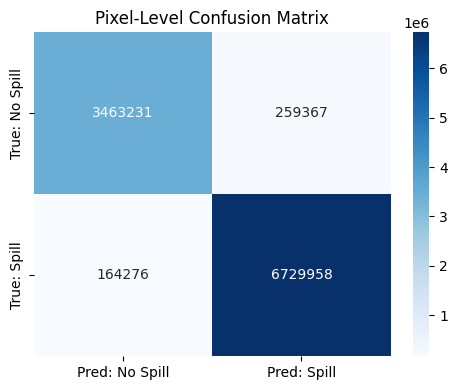

In [ ]:
cm = final_metrics["confusion_matrix"]
cm_array = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])

plt.figure(figsize=(5, 4))
sns.heatmap(cm_array, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: No Spill", "Pred: Spill"],
            yticklabels=["True: No Spill", "True: Spill"])
plt.title("Pixel-Level Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(CFG.plots_dir, "confusion_matrix.png")) # Save plot
plt.show()

<a id="13"></a>
## 13. Qualitative Results & Error Analysis

Side-by-side image / ground-truth / prediction, plus a per-pixel error map:
🟩 correct detection · 🟨 false positive · 🟥 missed spill.

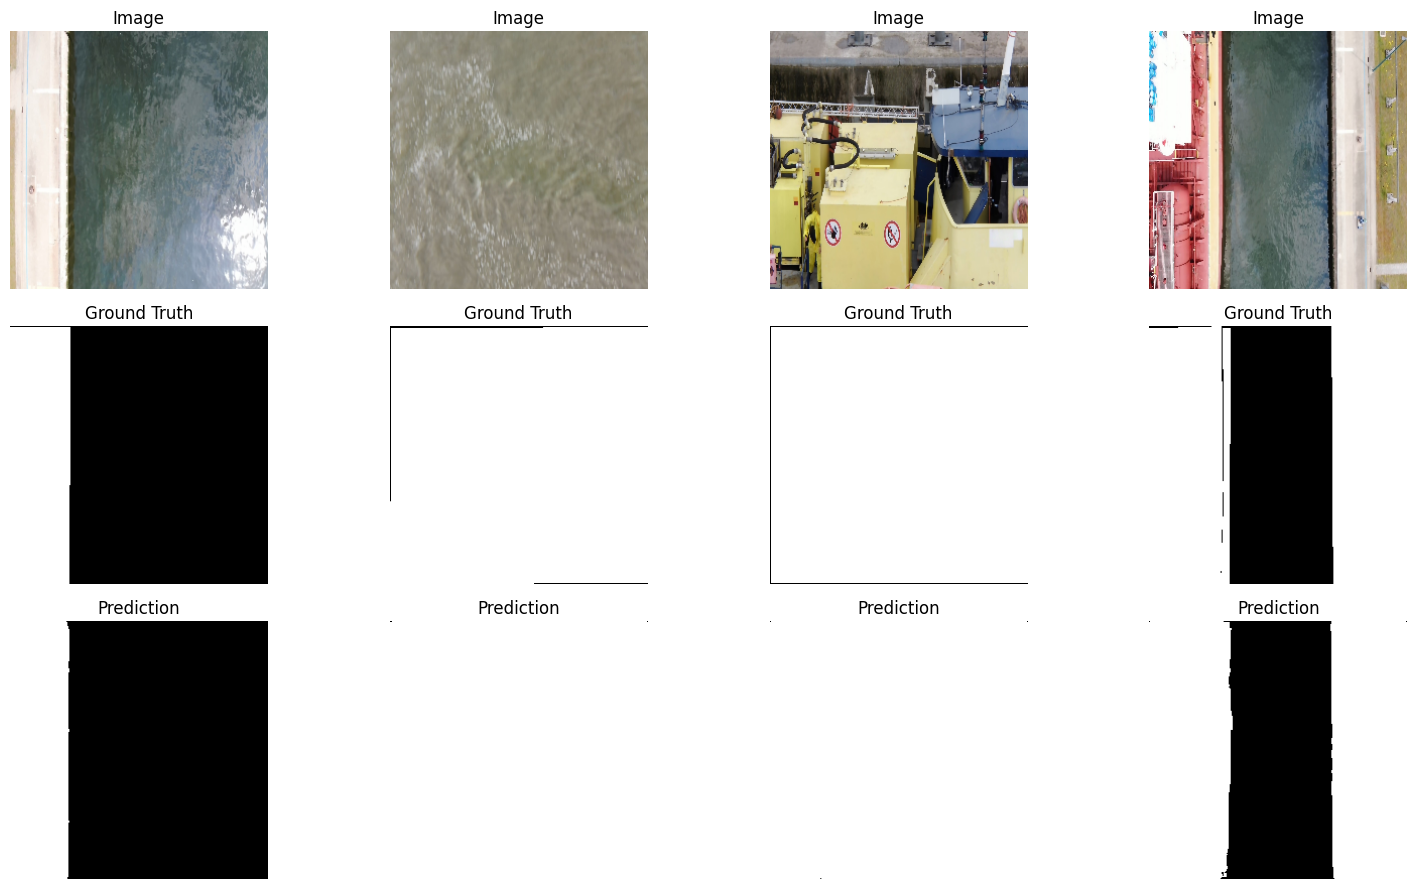

In [ ]:
images, masks = next(iter(val_loader))
images = images.to(DEVICE)

with torch.no_grad():
    preds_binary = (torch.sigmoid(best_model(images)) > 0.5).float()

images_cpu, masks_cpu, preds_cpu = images.cpu(), masks.cpu(), preds_binary.cpu()
n_show = min(4, len(images))

plt.figure(figsize=(4 * n_show, 9))
for i in range(n_show):
    plt.subplot(3, n_show, i + 1)
    plt.imshow(np.transpose(images_cpu[i].numpy(), (1, 2, 0))); plt.title("Image"); plt.axis("off")

    plt.subplot(3, n_show, n_show + i + 1)
    plt.imshow(masks_cpu[i].squeeze(), cmap="gray"); plt.title("Ground Truth"); plt.axis("off")

    plt.subplot(3, n_show, 2 * n_show + i + 1)
    plt.imshow(preds_cpu[i].squeeze(), cmap="gray"); plt.title("Prediction"); plt.axis("off")
plt.tight_layout()
plt.show()

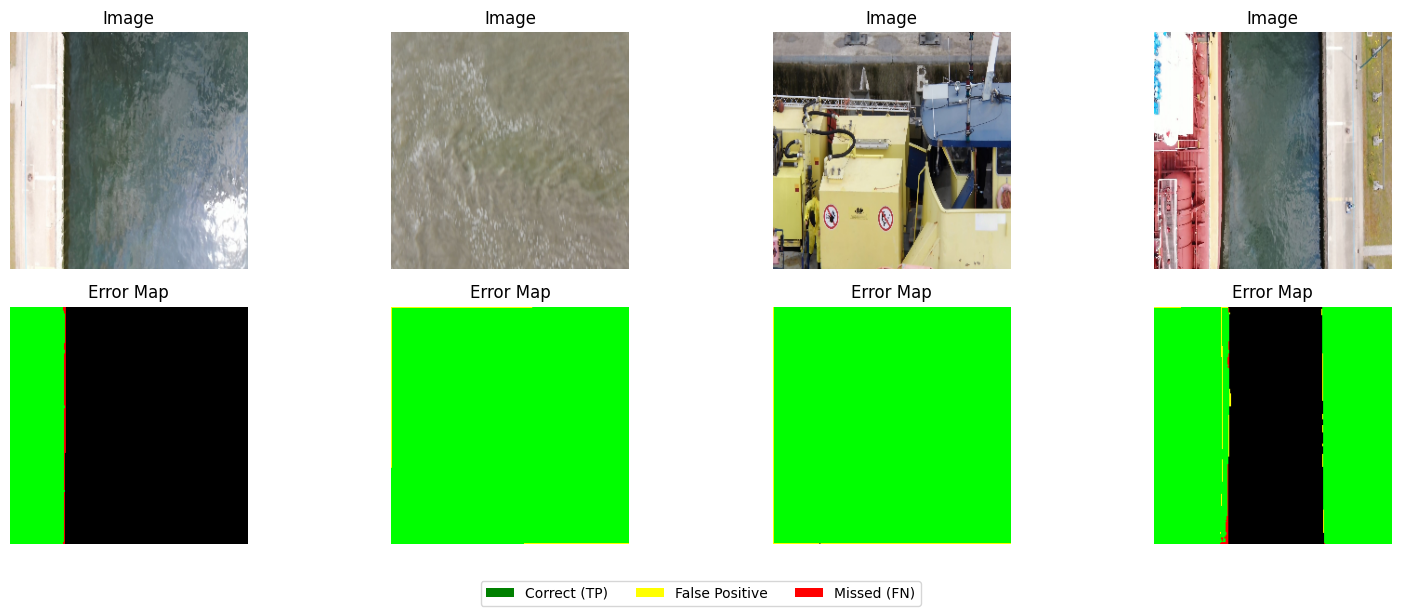

In [ ]:
plt.figure(figsize=(4 * n_show, 6))
for i in range(n_show):
    true_mask = masks_cpu[i].squeeze().numpy()
    pred_mask = preds_cpu[i].squeeze().numpy()

    error_map = np.zeros((*true_mask.shape, 3), dtype=np.float32)
    error_map[(true_mask == 1) & (pred_mask == 1)] = [0, 1, 0]  # TP
    error_map[(true_mask == 0) & (pred_mask == 1)] = [1, 1, 0]  # FP
    error_map[(true_mask == 1) & (pred_mask == 0)] = [1, 0, 0]  # FN

    plt.subplot(2, n_show, i + 1)
    plt.imshow(np.transpose(images_cpu[i].numpy(), (1, 2, 0))); plt.title("Image"); plt.axis("off")

    plt.subplot(2, n_show, n_show + i + 1)
    plt.imshow(error_map); plt.title("Error Map"); plt.axis("off")

green = plt.Rectangle((0, 0), 1, 1, fc="green")
yellow = plt.Rectangle((0, 0), 1, 1, fc="yellow")
red = plt.Rectangle((0, 0), 1, 1, fc="red")
plt.figlegend([green, yellow, red],
              ["Correct (TP)", "False Positive", "Missed (FN)"],
              loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

<a id="14"></a>
## 14. Test-Time Augmentation (optional accuracy boost)

TTA runs inference on a few flipped/rotated copies of each image and averages the predicted
probabilities. It's essentially free (no retraining) and typically adds a small but real bump to
IoU/Dice by canceling out orientation-specific mistakes. Toggle `CFG.use_tta = True` to use this
version of evaluation instead of the single-pass one in Section 12.

In [ ]:
def predict_with_tta(model, image_tensor):
    # image_tensor: (B, C, H, W), already normalized. Returns averaged probability map.
    transforms_and_inverses = [
        (lambda x: x, lambda x: x),
        (lambda x: torch.flip(x, dims=[3]), lambda x: torch.flip(x, dims=[3])),
        (lambda x: torch.flip(x, dims=[2]), lambda x: torch.flip(x, dims=[2])),
        (lambda x: torch.rot90(x, k=2, dims=[2, 3]), lambda x: torch.rot90(x, k=2, dims=[2, 3])),
    ]
    probs_sum = None
    with torch.no_grad():
        for forward_tf, inverse_tf in transforms_and_inverses:
            aug_input = forward_tf(image_tensor)
            pred = torch.sigmoid(model(aug_input))
            pred = inverse_tf(pred)
            probs_sum = pred if probs_sum is None else probs_sum + pred
    return probs_sum / len(transforms_and_inverses)

if CFG.use_tta:
    tta_accumulator = MetricAccumulator()
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            probs = predict_with_tta(best_model, x).squeeze(1)
            tta_accumulator.update(probs, y)
    tta_metrics = tta_accumulator.compute()
    print_metrics(tta_metrics, title="Final Validation Performance (with TTA)")
    print(f"\nIoU change vs. single-pass: {(tta_metrics['iou'] - final_metrics['iou']) * 100:+.2f} pts")
else:
    print("CFG.use_tta is False — set it to True above and re-run this cell to compare.")

CFG.use_tta is False — set it to True above and re-run this cell to compare.


<a id="15"></a>
## 15. Architecture Comparison Harness (optional)

If you want an actual answer to "which model is best on *my* data" rather than a guess, this
trains a short run of each configuration in `CANDIDATES` and puts final validation IoU/Dice/F1
side by side. It's off by default (`RUN_COMPARISON = False`) because it multiplies your training
time by the number of candidates — turn it on once you have a working single run and some GPU
time to spare, and consider dropping `comparison_epochs` if you just want a quick signal rather
than a fully converged comparison.

In [ ]:
RUN_COMPARISON = False   # set True to actually run this section
comparison_epochs = 15   # shorter than a full run — enough to rank candidates, not to finalize one

CANDIDATES = [
    {"architecture": "unet", "encoder_name": "resnet34", "loss_type": "dice_bce"},
    {"architecture": "unet", "encoder_name": "resnet34", "loss_type": "dice_focal"},
    {"architecture": "unet", "encoder_name": "resnet50", "loss_type": "dice_focal"},
    {"architecture": "deeplabv3plus", "encoder_name": "resnet34", "loss_type": "dice_focal"},
]

def train_candidate(candidate, epochs=comparison_epochs):
    cand_model = build_model(architecture=candidate["architecture"], encoder_name=candidate["encoder_name"])
    cand_loss_fn = build_loss(candidate["loss_type"])
    cand_optimizer = optim.Adam(cand_model.parameters(), lr=CFG.learning_rate)
    cand_scheduler = optim.lr_scheduler.CosineAnnealingLR(cand_optimizer, T_max=epochs)

    best_iou = -1.0
    for _ in range(epochs):
        run_train_epoch(train_loader, cand_model, cand_optimizer, cand_loss_fn)
        _, val_metrics = run_val_epoch(val_loader, cand_model, cand_loss_fn)
        cand_scheduler.step()
        best_iou = max(best_iou, val_metrics["iou"])

    _, final_val_metrics = run_val_epoch(val_loader, cand_model, cand_loss_fn)
    return final_val_metrics

if RUN_COMPARISON:
    results = []
    for candidate in CANDIDATES:
        label = f"{candidate['architecture']}/{candidate['encoder_name']}/{candidate['loss_type']}"
        print(f"\n=== Training candidate: {label} ===")
        metrics = train_candidate(candidate)
        results.append({"candidate": label, **metrics})

    import pandas as pd
    comparison_df = pd.DataFrame(results)[["candidate", "iou", "dice", "f1", "precision", "recall"]]
    comparison_df = comparison_df.sort_values("iou", ascending=False).reset_index(drop=True)
    print("\n=== Comparison (sorted by IoU) ===")
    display(comparison_df)
else:
    print("RUN_COMPARISON is False — flip it to True above to actually run the comparison.")

RUN_COMPARISON is False — flip it to True above to actually run the comparison.


<a id="16"></a>
## 16. Streamlit App

Writes `app.py`: a three-page app (Home → Upload & Detect → Analysis) that loads the checkpoint
saved above, runs inference on uploaded images, overlays the predicted spill mask, and charts
spill % per image. Wallpaper images are optional — the app falls back gracefully if they're
missing instead of erroring out. The model architecture/encoder used for inference is read from
the checkpoint's saved config, so this stays in sync automatically if you change `CFG.architecture`
above and retrain.

In [ ]:
!pip install --upgrade streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 48.1 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import torch
import segmentation_models_pytorch as smp
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from datetime import datetime
import os
import base64

st.set_page_config(page_title="Oil Spill Detection", page_icon="🌊", layout="wide")

# --- CONFIG (edit these to match your Drive layout) ---
MODEL_PATH = "/content/drive/MyDrive/best_model_custom_unet.pth.tar"
WALLPAPERS = {
    "home": "/content/drive/MyDrive/wallpaper2.jpg",
    "upload": "/content/drive/MyDrive/wallpaper1.png",
    "analysis": "/content/drive/MyDrive/wallpaper4.jpg",
}

def get_base64_image(path):
    if not path or not os.path.exists(path):
        return ""
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()

def inject_css(page="home"):
    b64_img = get_base64_image(WALLPAPERS.get(page))
    bg_rule = f'background-image: url("data:image/jpg;base64,{b64_img}");' if b64_img else "background: #10141f;"
    st.markdown(f"""
        <style>
        .stApp {{
            {bg_rule}
            background-size: cover; background-position: center;
            background-repeat: no-repeat; background-attachment: fixed;
            color: #e2ecf6 !important;
        }}
        .main-content {{
            background: rgba(22,28,48,0.85); padding: 2.2rem 2.5rem;
            border-radius: 24px; margin: 2.5rem auto; max-width: 850px;
            box-shadow: 0 8px 20px rgba(0,0,0,0.6);
        }}
        h1, h2, h3, .stMarkdown, .stSelectbox label, .stSlider label {{ color: #31cafb; }}
        div.stButton > button {{
            background-color: #fe4a49 !important; color: white !important;
            border-radius: 36px !important; font-weight: 700 !important;
            font-size: 18px !important; border: none !important;
        }}
        div.stButton > button:hover {{ background-color: #95231a !important; }}
        .stDataFrame, .stTable {{
            color: #e2ecf6;
            background-color: rgba(22,28,48,0.85);
            border-radius: 12px;
            padding: 1rem;
        }}
        .stDataFrame th, .stDataFrame td {{
            background-color: transparent;
            color: #e2ecf6;
        }}
        .stTabs [data-baseweb="tab-list"] button [data-testid="stMarkdownContainer"] p {{
            font-size:1.2rem;
        }}
        </style>
    """, unsafe_allow_html=True)

@st.cache_resource
def load_model():
    if not os.path.exists(MODEL_PATH):
        st.error(f"Model checkpoint not found at {MODEL_PATH}")
        return None
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)

    saved_cfg = ckpt.get("config", {})
    architecture = saved_cfg.get("architecture", "unet")
    encoder_name = saved_cfg.get("encoder_name", "resnet34")

    if architecture == "deeplabv3plus":
        model = smp.DeepLabV3Plus(encoder_name, encoder_weights=None, in_channels=3, classes=1)
    else:
        model = smp.Unet(encoder_name, encoder_weights=None, in_channels=3, classes=1)

    model.load_state_dict(ckpt["state_dict"])
    return model.to(device).eval()

def preprocess(img, device):
    t = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.0, 0.0, 0.0], [1.0, 1.0, 1.0]),
    ])
    return t(img).unsqueeze(0).to(device)

def postprocess_mask(mask_tensor, size, threshold=0.5):
    mask = mask_tensor.squeeze().detach().cpu().numpy()
    mask = (mask > threshold).astype(np.uint8) * 255
    return Image.fromarray(mask).resize(size)

def overlay_mask(image, mask, color=(252, 46, 130)):
    image = image.convert("RGB")
    mask = mask.convert("L").resize(image.size)
    img_np, mask_np = np.array(image), np.array(mask)
    overlay_np = img_np.copy()
    overlay_np[mask_np == 255] = color
    return Image.fromarray(overlay_np)

def run_inference(img, model, device, threshold=0.5):
    tensor = preprocess(img, device)
    with torch.no_grad():
        out = model(tensor)
    mask_img = postprocess_mask(out, img.size, threshold=threshold)
    spill_px = np.array(mask_img).astype(bool).sum()
    spill_pct = 100 * spill_px / (mask_img.size[0] * mask_img.size[1])
    return overlay_mask(img, mask_img), spill_pct

def init_state():
    st.session_state.setdefault("page", "home")
    st.session_state.setdefault("uploaded", {})
    st.session_state.setdefault("results", [])

def nav_buttons(page):
    st.markdown("<br>", unsafe_allow_html=True)
    col_home, col_next = st.columns(2)
    if col_home.button("Back to Home", key=f"back_{page}", use_container_width=True):
        st.session_state.page = "home"
        st.rerun()
    if page == "upload" and col_next.button("Go to Analysis", key="goto_analysis", use_container_width=True):
        st.session_state.page = "analysis"
        st.rerun()
    elif page == "analysis" and col_next.button("Go to Upload", key="goto_upload", use_container_width=True):
        st.session_state.page = "upload"
        st.rerun()

def page_home():
    inject_css("home")
    st.markdown('<div class="main-content">', unsafe_allow_html=True)
    st.title("🌊 Oil Spill Detection")
    st.markdown(
        "<p style='text-align:center;font-size:1.15rem;'>Upload satellite images and get "
        "spill regions highlighted instantly, with per-image analytics.</p>",
        unsafe_allow_html=True,
    )
    col_upload, col_analysis = st.columns(2)
    if col_upload.button("Upload & Detect", use_container_width=True):
        st.session_state.page = "upload"; st.rerun()
    if col_analysis.button("View Analysis", use_container_width=True):
        st.session_state.page = "analysis"; st.rerun()
    st.markdown("</div>", unsafe_allow_html=True)

def page_upload(model, device):
    inject_css("upload")
    st.markdown('<div class="main-content">', unsafe_allow_html=True)
    st.header("Upload Images for Detection")

    with st.sidebar:
        st.header("Configuration")
        files = st.file_uploader("Select images (JPG/PNG)", type=["jpg", "jpeg", "png"], accept_multiple_files=True)
        alert_threshold = st.slider("Alert threshold (spill %)", 1, 99, 10)
        display_threshold = st.slider("Mask display threshold (0.0-1.0)", 0.0, 1.0, 0.5, 0.05)

        if files:
            for f in files:
                if f.name not in st.session_state.uploaded:
                    st.session_state.uploaded[f.name] = Image.open(f).convert("RGB")

            if st.button("Run Detection", use_container_width=True, key="run_detection_sidebar"):
                st.session_state.results = []
                with st.spinner("Detecting spills..."):
                    for name, img in st.session_state.uploaded.items():
                        overlay, pct = run_inference(img, model, device, threshold=display_threshold)
                        st.session_state.results.append({
                            "name": name, "original": img, "overlay": overlay,
                            "spill_pct": pct,
                            "alert": "Critical" if pct >= alert_threshold else "Normal",
                            "time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                        })
                st.success("Detection finished — check the Analysis page.")

    if st.session_state.uploaded:
        st.subheader("Uploaded Images Preview")
        cols = st.columns(min(3, len(st.session_state.uploaded)))
        for i, (name, img) in enumerate(st.session_state.uploaded.items()):
            with cols[i % 3]:
                st.image(img, caption=name, use_column_width=True)

    nav_buttons("upload")
    st.markdown("</div>", unsafe_allow_html=True)

def page_analysis():
    inject_css("analysis")
    st.markdown('<div class="main-content">', unsafe_allow_html=True)
    st.header("Detection Analysis")

    if not st.session_state.results:
        st.warning("No results yet — run detection on the Upload page first.")
        nav_buttons("analysis")
        st.markdown("</div>", unsafe_allow_html=True)
        return

    df = pd.DataFrame([
        {"Image": r["name"], "Spill Area %": f"{r['spill_pct']:.2f}%", "Alert": r["alert"], "Time": r["time"]}
        for r in st.session_state.results
    ])

    st.subheader("Overall Summary")
    col1, col2, col3 = st.columns(3)
    col1.metric("Images Analyzed", len(df))
    col2.metric("Average Spill Area", f"{pd.to_numeric(df['Spill Area %'].str.replace('%', '')).mean():.2f}%")
    col3.metric("Critical Alerts", int((df["Alert"] == "Critical").sum()))

    st.subheader("Spill Percentage by Image")
    df_plot = df.copy()
    df_plot['Spill Area %'] = pd.to_numeric(df_plot['Spill Area %'].str.replace('%', ''))
    fig = go.Figure(go.Bar(x=df_plot["Image"], y=df_plot["Spill Area %"], marker_color="#31cafb"))
    fig.update_layout(title="", plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)",
                      font_color="#e2ecf6", xaxis_title="Image", yaxis_title="Spill Area %")
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Detailed Image Results")
    tabs = st.tabs([res["name"] for res in st.session_state.results])
    for i, res in enumerate(st.session_state.results):
        with tabs[i]:
            st.write(f"**Image:** {res['name']}")
            st.write(f"**Spill Area:** {res['spill_pct']:.2f}%")
            st.write(f"**Alert Level:** {res['alert']}")
            st.image([res["original"], res["overlay"]], caption=["Original Image", "Detection Overlay"], width=350)

    nav_buttons("analysis")
    st.markdown("</div>", unsafe_allow_html=True)

def main():
    init_state()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = load_model()
    if model is None:
        st.stop()

    if st.session_state.page == "home":
        page_home()
    elif st.session_state.page == "upload":
        page_upload(model, device)
    elif st.session_state.page == "analysis":
        page_analysis()

if __name__ == "__main__":
    main()

Overwriting app.py


<a id="17"></a>
## 17. Deployment (public tunnel)

Runs the Streamlit app in the background and exposes it through a temporary public URL — handy
for demoing from Colab. The ngrok authtoken is entered securely at runtime (never hardcoded),
and any process left running from a previous cell execution is killed first so re-running this
cell doesn't collide with a stale server.

In [ ]:
!npm install -g localtunnel -q

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 2s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧

In [ ]:
import os
os.system("pkill -f streamlit")
os.system("pkill -f ngrok")

15

In [ ]:
!cat streamlit.log



2026-07-05 13:56:15.848 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.237.184:8501

2026-07-05 14:00:54.095 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-05 14:00:54.398 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-05 14:08:29.116 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-07-05 14:08:29.123 Plea

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

import os
import socket
import time

# Kill previous processes
os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")

# Start Streamlit
os.system("streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > streamlit.log 2>&1 &")

# Wait until Streamlit is actually running
for _ in range(60):
    s = socket.socket()
    if s.connect_ex(("127.0.0.1", 8501)) == 0:
        s.close()
        print("✅ Streamlit is running!")
        break
    s.close()
    time.sleep(1)
else:
    print("❌ Streamlit failed to start.")
    !cat streamlit.log
    raise SystemExit

# Start Cloudflare Tunnel
!./cloudflared-linux-amd64 tunnel --url http://127.0.0.1:8501

✅ Streamlit is running!
2026-07-05T14:14:49Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-05T14:14:49Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-05T14:14:52Z INF +--------------------------------------------------------------------------------------------+
2026-07-05T14:14:52Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-05T14:14:52Z INF |  https://wiley-valium-opponent

---

### 🧭 Where to go from here

- **Run Section 15** once you have a working baseline and some spare GPU time — it's the actual
  data-driven way to answer "which architecture/loss wins on my dataset" instead of guessing.
- **More data / harder negatives** is still the single biggest lever for real-world robustness:
  clean-ocean scenes that superficially resemble spills (algae blooms, sun glint, cloud shadow)
  teach the model what to rule out, which a metrics-only view of the current dataset can't tell you.
- **Post-processing** — a small morphological open/close pass on the predicted mask can remove
  speckle noise without materially changing IoU.
- **Serving beyond Colab** — once you're happy with the model, `app.py` + `requirements.txt` runs
  unmodified on Streamlit Community Cloud, Hugging Face Spaces, or a small VM — no ngrok needed.